In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import time
import datetime

In [ ]:
train = pd.read_csv(f"../datasets/fraud_sparkov/fraudTrain.csv")
test = pd.read_csv(f"../datasets/fraud_sparkov/fraudTest.csv")
df = pd.concat([train,test], axis=0)

In [3]:
df = df.drop("Unnamed: 0", axis=1)

In [4]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
print(len(df), len(train)+len(test))

1852394 1852394


In [ ]:
g = df.groupby(by="cc_num")["merchant"].count().sort_values(ascending=False)

cc_num
6538441737335434       4392
30270432095985         4392
6538891242532018       4386
4642255475285942       4386
4364010865167176       4386
                       ... 
3545578418030657          7
6577777028615915          7
4975457191020             7
4352307151555405069       7
4295296907373             6
Name: merchant, Length: 999, dtype: int64

In [7]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

df['distance_km'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)

In [8]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["trans_date_trans_time"] = df["trans_date_trans_time"].map(pd.Timestamp.timestamp)
df["step"] = pd.cut(df["trans_date_trans_time"],bins=1000, labels=False)
df["step"] = df["step"] + 1

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df["trans_date_trans_time"] = scaler.fit_transform(df[["trans_date_trans_time"]])

In [55]:
df["name"] = df["first"] + ' ' + df["last"]

In [10]:
year = df["dob"].str[:4].astype(int)
df["age"] = 2020 - year # dataset released in 2020

In [11]:
toDrop = ['first', 'last','street',
          'zip','dob','trans_num',
          'unix_time', 'lat', 'long',
          'merch_lat', 'merch_long', 'trans_date_trans_time']
dfClean = df.drop(toDrop, axis=1)

In [12]:
dfClean.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state',
       'city_pop', 'job', 'is_fraud', 'distance_km', 'step', 'age'],
      dtype='object')

In [ ]:
catCols = ['merchant','category', 'city', 'gender','state', 'job']
def checkUniqueCounts(dataFrame: pd.DataFrame, colNames: list[str]):
    for col in colNames:
        uniques =dataFrame[col].unique()
        print(f"len of {col}: {len(uniques)}")

checkUniqueCounts(dfClean, colNames=catCols)

len of merchant: 693
len of category: 14
len of city: 906
len of gender: 2
len of state: 51
len of job: 497


In [14]:
from sklearn.preprocessing import LabelEncoder

dfClean["merchant"] = LabelEncoder().fit_transform(dfClean["merchant"])
dfClean["category"] = LabelEncoder().fit_transform(dfClean["category"])
dfClean["city"] = LabelEncoder().fit_transform(dfClean["city"])
dfClean["state"] = LabelEncoder().fit_transform(dfClean["state"])
dfClean["job"] = LabelEncoder().fit_transform(dfClean["job"])
dfClean["gender"] = (dfClean["gender"] == "M").astype(int)

In [ ]:
dfClean["amt"] = np.log1p(dfClean["amt"])
dfClean["city_pop"] = np.log1p(dfClean["city_pop"])

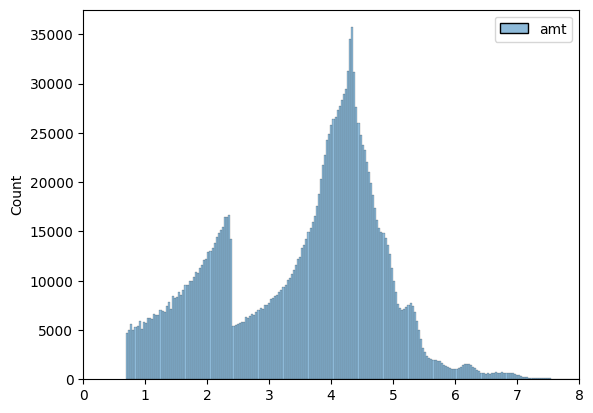

In [16]:
sns.histplot(dfClean[["amt"]])
plt.xlim([0,8])
plt.show()

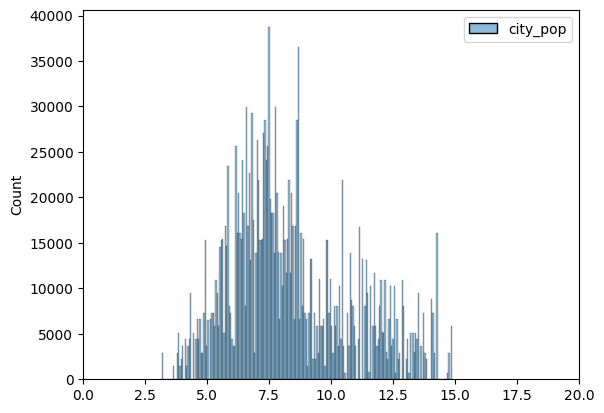

In [17]:
sns.histplot(dfClean[["city_pop"]])
plt.xlim([0,20])
plt.show()

In [18]:
corrCols = ['cc_num', 'merchant','category','gender','city','state','job']
corrDf = dfClean.drop(corrCols, axis=1)

In [19]:
dfClean.head()

,cc_num,merchant,category,amt,gender,city,state,city_pop,job,is_fraud,distance_km,step,age
0,2703186189652095,514,8,1.786747,0,532,27,8.159375,372,0,78.597568,1,32
1,630423337322,241,4,4.684259,0,619,47,5.010635,431,0,30.212176,1,42
2,38859492057661,390,0,5.398660,1,474,13,8.332068,308,0,108.206083,1,58
3,3534093764340240,360,2,3.828641,1,84,26,7.570443,330,0,95.673231,1,53
4,375534208663984,297,9,3.760269,1,217,45,4.605170,116,0,77.556744,1,34


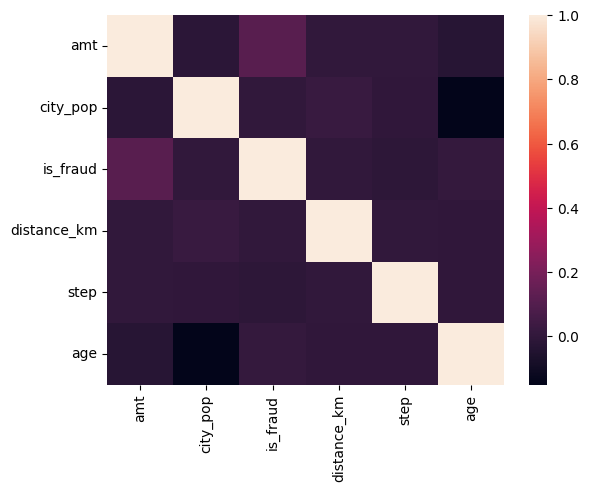

amt            0.114310
city_pop       0.001418
is_fraud       1.000000
distance_km    0.000359
step          -0.013310
age            0.011103
Name: is_fraud, dtype: float64


In [20]:
corrMatrix = corrDf.corr()
sns.heatmap(corrMatrix)
plt.show()
print(corrMatrix["is_fraud"])

In [22]:
dfClean.head()

,cc_num,merchant,category,amt,gender,city,state,city_pop,job,is_fraud,distance_km,step,age
0,2703186189652095,514,8,1.786747,0,532,27,8.159375,372,0,78.597568,1,32
1,630423337322,241,4,4.684259,0,619,47,5.010635,431,0,30.212176,1,42
2,38859492057661,390,0,5.398660,1,474,13,8.332068,308,0,108.206083,1,58
3,3534093764340240,360,2,3.828641,1,84,26,7.570443,330,0,95.673231,1,53
4,375534208663984,297,9,3.760269,1,217,45,4.605170,116,0,77.556744,1,34


In [38]:
dfClean['time_since_last_txn'] = dfClean.groupby('cc_num')['step'].diff()

In [54]:
isZero = (dfClean["time_since_last_txn"] == 0).sum()
isNeg = (dfClean["time_since_last_txn"] < 0).sum()
isPos = (dfClean["time_since_last_txn"] > 0).sum()
print(isZero,isNeg,isPos)

1159077 263 693054


In [ ]:
g_name_cc = df.groupby(by=["name"])["cc_num"].count().sort_values(ascending=False)

name
Scott Martin         6583
Jeffrey Smith        5118
Lisa Lin             4392
Gina Grimes          4392
Linda Davis          4389
                     ... 
Christina Norris        7
Danielle Schaefer       7
Kelly Lawrence          7
Mark Pennington         7
Destiny Fowler          6
Name: cc_num, Length: 989, dtype: int64

In [ ]:
df.groupby(by=["cc_num"])["name"].count().sort_values(ascending=False)

cc_num
6538441737335434       4392
30270432095985         4392
6538891242532018       4386
4642255475285942       4386
4364010865167176       4386
                       ... 
3545578418030657          7
6577777028615915          7
4975457191020             7
4352307151555405069       7
4295296907373             6
Name: name, Length: 999, dtype: int64

In [74]:
g_name_isfraud = df.groupby(by=["name", "is_fraud"])["is_fraud"].sum().sort_values(ascending=False)
g_name_isfraud

name            is_fraud
Scott Martin    1           27
Jennifer Scott  1           26
Robert James    1           22
Jeffrey Smith   1           20
Linda Davis     1           20
                            ..
Mary Diaz       0            0
Mary Humphrey   0            0
Mary Juarez     0            0
Mary Lewis      0            0
Edward Sanchez  0            0
Name: is_fraud, Length: 1868, dtype: int64

In [ ]:
dfClean["time_since_last_txn"] = dfClean["time_since_last_txn"].fillna(dfClean["step"])
print(dfClean["time_since_last_txn"].sort_values(ascending=False))

506021    986.0
422405    959.0
342954    917.0
328127    908.0
327231    907.0
          ...  
100558     -1.0
100557     -1.0
100556     -1.0
100555     -1.0
100553     -1.0
Name: time_since_last_txn, Length: 1852394, dtype: float64


In [47]:
print(df["step"].iloc[100557])

80
